# 作業四 (due 4/21/2026)
資工二 113590021 邱冠勛

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

#在Jupyter Notebook上顯示圖表所必需的　magic command,
%matplotlib inline

### 1. 題目一
請繪製台積電在2025年的收盤價及開盤價的趨勢圖。

In [35]:
data = pd.read_csv('./data_science_data2025.csv',index_col=0)

#提取資料
data = data[['date', '證券名稱', '開盤價', '收盤價']]

#更改名字
data = data.rename(columns = {
    '證券名稱':'name',
    '開盤價':'opening_price',
    '收盤價':'closing_price'
})

#清理資料
data['opening_price'] = data['opening_price'].replace({'$':'', ',':'', '--':np.nan}, regex=True)
data['closing_price'] = data['closing_price'].replace({'$':'', ',':'', '--':np.nan}, regex=True)
data = data.dropna()

#更改資料型態
data['opening_price'] = data['opening_price'].astype('float64')
data['closing_price'] = data['closing_price'].astype('float64')
data['date'] = pd.to_datetime(data['date'])

In [36]:
# 取用台積電的資料
data_group = data.groupby('name')
data_TSMC = data_group.get_group("台積電").reset_index(drop=True)

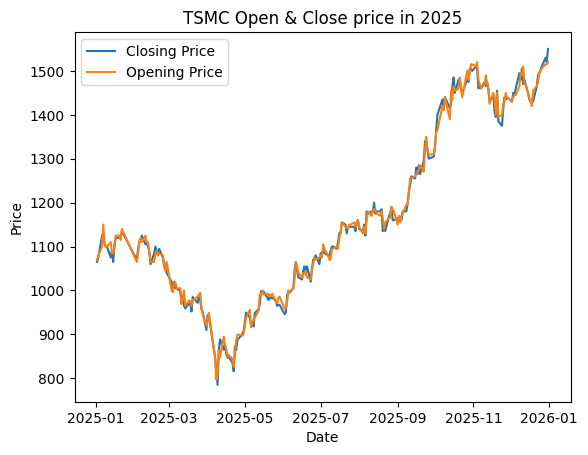

In [37]:
plt.plot(data_TSMC['date'], data_TSMC['closing_price'], label='Closing Price')
plt.plot(data_TSMC['date'], data_TSMC['opening_price'], label='Opening Price')
plt.legend(loc='best')

#x坐標軸
plt.ylabel("Price")
plt.xlabel("Date")

#標題
plt.title("TSMC Open & Close price in 2025")
plt.show()

### 2. 題目二:
請分析2025/1/1-2025/12/31期間與台積電絕對值相關度排行第5名的股票是哪一支股票？ <br>
劃出這兩支股票的股價圖表 (圖表必須包含圖例、座標軸名稱、標題、大小為(7,7))

In [38]:
#製作一個新的dataframe，可以儲存與中信金進行相關度分析的資料
data_CH_corr_company = pd.DataFrame()

#製作所有上市公司的list，方法 : 將data的name這個columns刪除重複項即可
companies = data['name'].drop_duplicates()
data_CH_corr_company['company'] = companies
data_CH_corr_company['corr'] = 0

data_TSMC = data_TSMC.set_index('date')

#使用apply遍歷所有公司與中信金相關度的分析
def get_corr(x):
    data_company = data[data['name']==x].set_index('date')
    return data_TSMC['closing_price'].corr(data_company['closing_price'])

data_CH_corr_company['corr'] = data_CH_corr_company['company'].apply(get_corr)

In [ ]:
data_CH_corr_company['corr'] = data_CH_corr_company['corr'].abs()
data_CH_corr_company = data_CH_corr_company.sort_values('corr', ascending = False)

fifth_company = data_CH_corr_company.iloc[5].company

data_fifth = data_group.get_group(fifth_company).set_index('date')

#將中信金與國泰金merge起來，請參考lab5
data_TSMC_FIFTH = pd.merge(data_TSMC[['closing_price']], data_fifth[['closing_price']], on='date', suffixes=('_TSMC', '_Fifth'))

,company,corr
310652,主動台新優勢成長,1.000000
310657,主動群益科技創新,1.000000
486,台積電,1.000000
6,富邦摩台,0.996722
13,富邦台50,0.996237
...,...,...
247,上曜,0.003097
371,和桐,0.002861
249,大洋,0.002512
925,日成-KY,0.001448


/home/yfhd/Documents/114-2/Data Science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yfhd/Documents/114-2/Data Science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yfhd/Documents/114-2/Data Science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yfhd/Documents/114-2/Data Science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28771 (\N{CJK UNIFIED IDEOGRAPH-7063}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


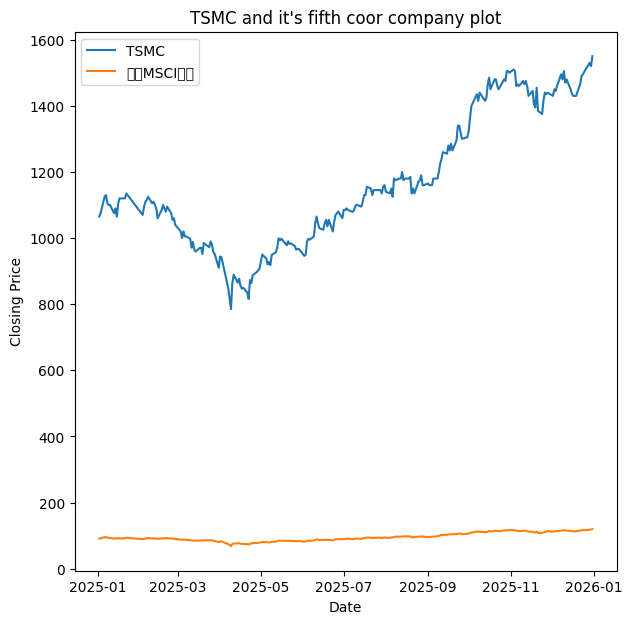

In [ ]:
plt.figure(figsize=(7, 7))

plt.plot(data_TSMC_FIFTH["closing_price_TSMC"], label='TSMC')
plt.plot(data_TSMC_FIFTH["closing_price_Fifth"], label=fifth_company)
plt.legend(loc='best')

# x坐標軸
plt.ylabel("Closing Price")
plt.xlabel("Date")

# 標題
plt.title("TSMC and it's fifth coor company plot")
plt.show()